In [2]:
import numpy as np
import pandas as pd 
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve,roc_auc_score
from matplotlib import pyplot
from sklearn.model_selection import train_test_split


In [3]:
x,y=x,y=make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)
logistic=LogisticRegression()

In [4]:
dummy_model_prob = [0 for _ in range(len(y_test))]


In [5]:
model=LogisticRegression()
model.fit(x_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
#prediction based on probability 
model_prob=model.predict_proba(x_test)

In [7]:
model_prob=model_prob[:,-1]

In [8]:
dummy_model_auc=roc_auc_score(y_test,dummy_model_prob)
model_auc=roc_auc_score(y_test,model_prob)
print(dummy_model_auc)
print(model_auc)


0.5
0.9316726434426229


In [14]:
dummy_fpr,dummy_tpr,_=roc_curve(y_test,dummy_model_prob)
model_fpr,model_tpr,threshold=roc_curve(y_test,model_prob)


In [15]:
model_fpr,model_tpr

(array([0.        , 0.        , 0.        , 0.00819672, 0.00819672,
        0.01639344, 0.01639344, 0.02459016, 0.02459016, 0.03278689,
        0.03278689, 0.04098361, 0.04098361, 0.04918033, 0.04918033,
        0.06557377, 0.06557377, 0.07377049, 0.07377049, 0.09016393,
        0.09016393, 0.09836066, 0.09836066, 0.10655738, 0.10655738,
        0.13114754, 0.13114754, 0.13934426, 0.13934426, 0.1557377 ,
        0.1557377 , 0.17213115, 0.17213115, 0.18032787, 0.18032787,
        0.18852459, 0.18852459, 0.20491803, 0.20491803, 0.21311475,
        0.21311475, 0.23770492, 0.23770492, 0.26229508, 0.26229508,
        0.28688525, 0.28688525, 0.31147541, 0.31147541, 0.41803279,
        0.41803279, 0.45901639, 0.45901639, 0.54098361, 0.54098361,
        0.66393443, 0.66393443, 1.        ]),
 array([0.       , 0.0078125, 0.4765625, 0.4765625, 0.5078125, 0.5078125,
        0.5390625, 0.5390625, 0.5625   , 0.5625   , 0.59375  , 0.59375  ,
        0.640625 , 0.640625 , 0.6640625, 0.6640625, 0.6718

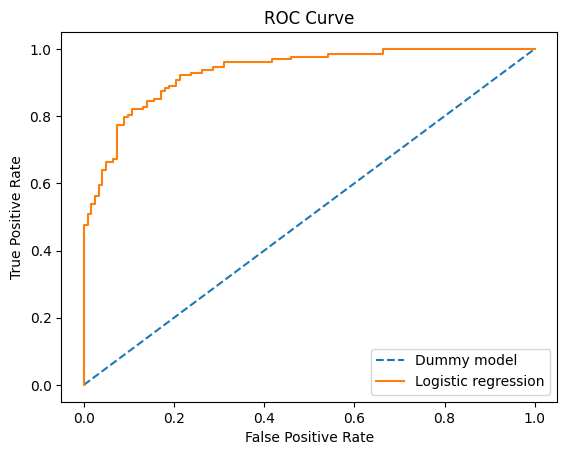

In [16]:


pyplot.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy model')
pyplot.plot(model_fpr, model_tpr, linestyle='-', label='Logistic regression')
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.title('ROC Curve')
pyplot.legend()
pyplot.show()

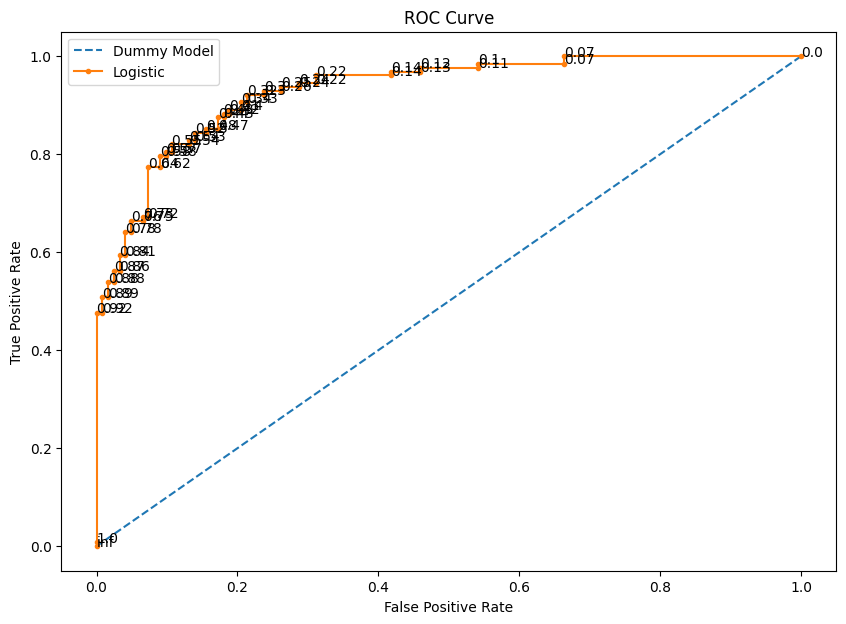

In [19]:
import numpy as np
from matplotlib import pyplot

fig = pyplot.figure(figsize=(10, 7))
ax = fig.add_subplot(111)

ax.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic')

# label the threshold at each point
for fpr, tpr, thr in zip(model_fpr, model_tpr, threshold):
    ax.annotate(f'{np.round(thr, 2)}', xy=(fpr, tpr))

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
pyplot.show()